<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Week6MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import savgol_filter

In [2]:
!wget -O apple_stock.zip "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip"

--2026-08-11 23:45:34--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip [following]
--2026-08-11 23:45:34--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP reque

In [3]:
import zipfile

with zipfile.ZipFile("apple_stock.zip", "r") as zip_ref:
    zip_ref.extractall("apple_stock")

In [4]:
import os

for root, dirs, files in os.walk("apple_stock"):
    for file in files:
        print(os.path.join(root, file))

apple_stock/Apple Stock Prices (1981 to 2023).csv


In [5]:
import glob

csv_files = glob.glob("apple_stock/**/*.csv", recursive=True)

print(csv_files)

['apple_stock/Apple Stock Prices (1981 to 2023).csv']


In [6]:
df = pd.read_csv(csv_files[0])

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


Examine the dataset

In [9]:
df.shape

(10608, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB


In [10]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


The Apple stock dataset contains daily historical information including opening price, high price, low price, closing price, adjusted closing price, and trading volume. The Date column was converted from text to datetime format using dayfirst=True because the dataset uses the day/month/year format. The data was then sorted chronologically. Missing values and data types were examined using info() and isnull(), while describe() was used to review the basic statistical properties of the numerical variables. The dataset represents trading days rather than every calendar day, so gaps occur during weekends and stock-market holidays.

Convert the Date column

In [13]:
df["Date"] = pd.to_datetime(df["Date"], format='%d/%m/%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10608 non-null  datetime64[ns]
 1   Open       10608 non-null  float64       
 2   High       10608 non-null  float64       
 3   Low        10608 non-null  float64       
 4   Close      10608 non-null  float64       
 5   Adj Close  10608 non-null  float64       
 6   Volume     10608 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 580.3 KB


In [14]:
df = df.sort_values("Date").reset_index(drop=True)

In [15]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Number of observations:", len(df))

Start date: 1981-01-02 00:00:00
End date: 2023-01-27 00:00:00
Number of observations: 10608


In [16]:
df["Date"].diff().value_counts().head()

,count
Date,
1 days,8317
3 days,1927
4 days,265
2 days,95
5 days,2


In [47]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
MA30,29
MA100,99
Year,0


The dataset contains 10,608 observations of Apple stock data from January 2, 1981 through January 27, 2023. The original financial variables contain no missing values. The Date column was converted to datetime format, while the stock price columns are numerical values and Volume represents the number of shares traded.

Some missing values appear in newly calculated variables such as the 30-day and 100-day moving averages and daily returns. These are expected because moving averages require a minimum number of previous observations, while the first daily return cannot be calculated because there is no previous trading day for comparison.

Overall, the dataset is clean and suitable for statistical and time-series analysis.

Data Visualization

Closing Price Over Time

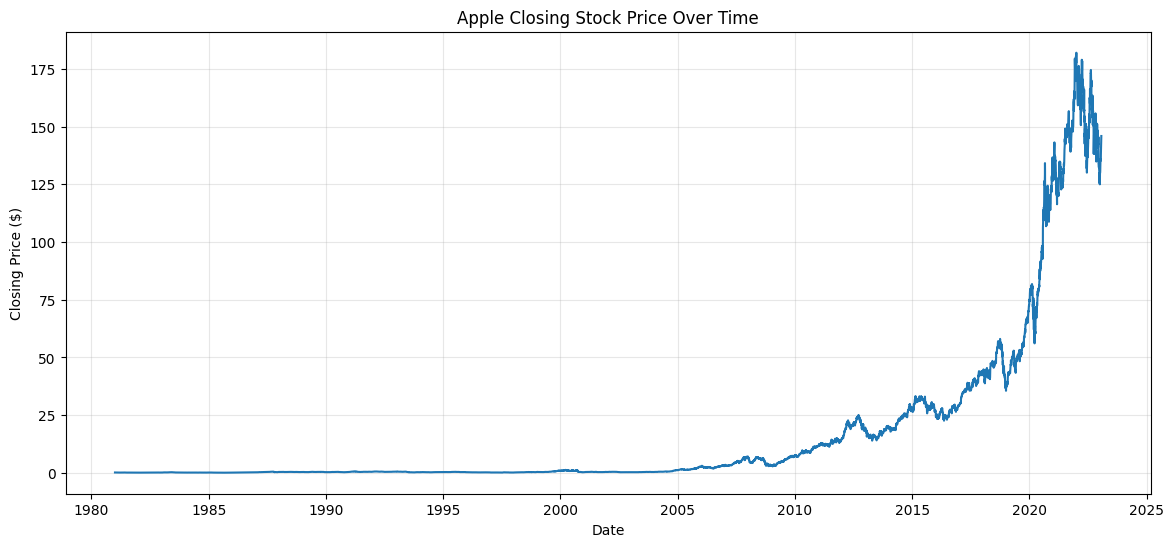

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("Apple Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.grid(alpha=0.3)

plt.show()

The closing-price graph demonstrates Apple's long-term stock price trend. Although the stock experienced periods of decline and volatility, the overall long-term trend is upward, particularly during the later years of the dataset.

Trading Volume Over Time

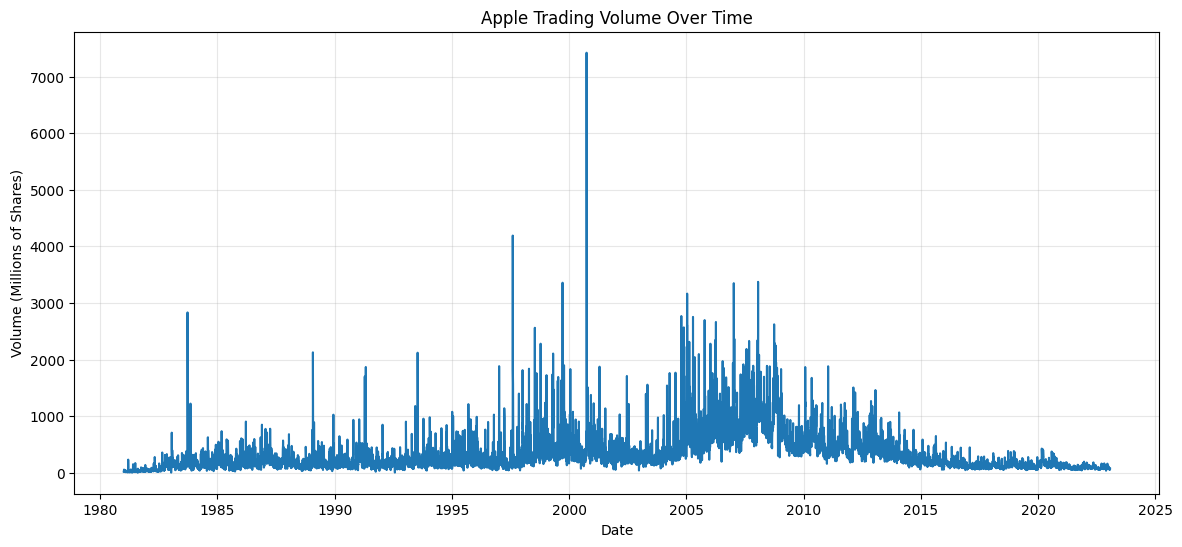

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Volume"] / 1_000_000)

plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume (Millions of Shares)")
plt.grid(alpha=0.3)

plt.show()

Trading volume varies considerably through time. Large spikes represent periods where unusually high numbers of Apple shares were traded, which may correspond with significant company announcements, market events, earnings reports, or increased investor activity.

Candlestick Chart

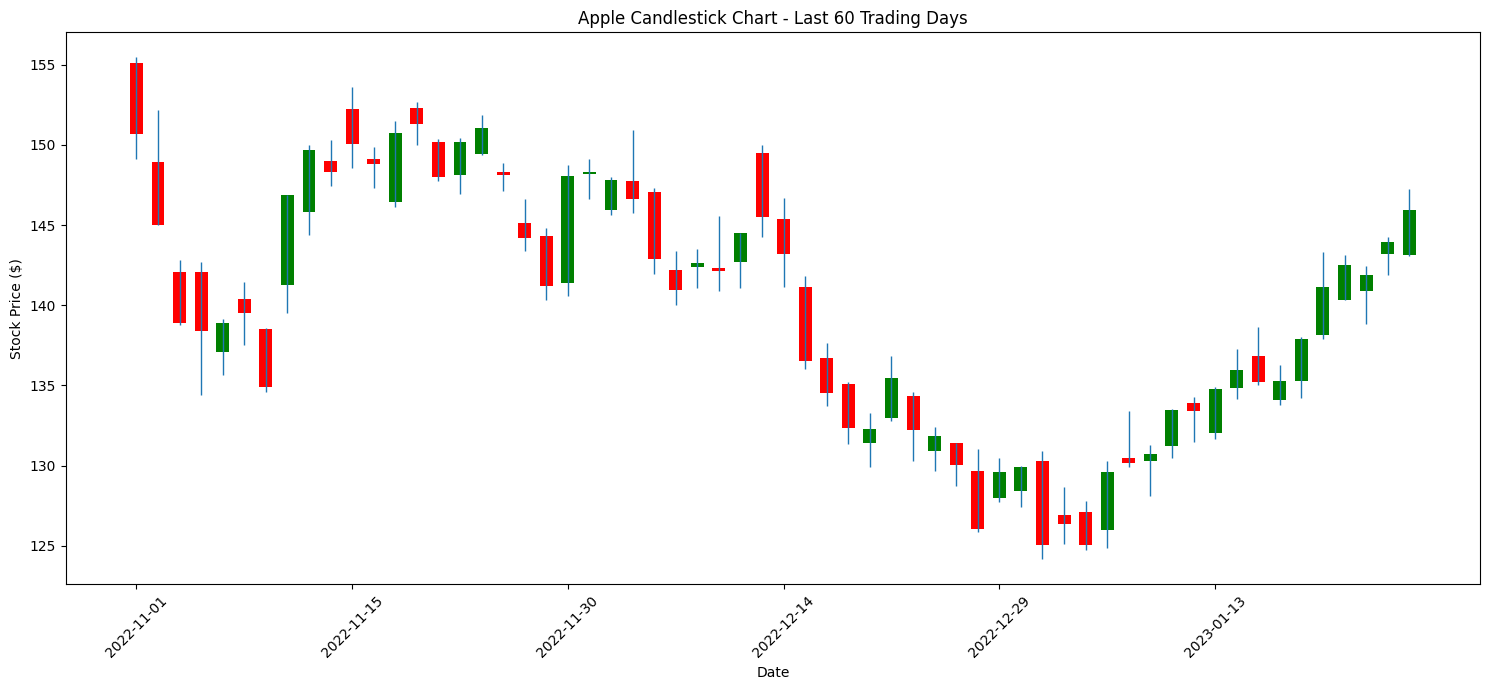

In [48]:
candles = df.tail(60).copy()
candles = candles.reset_index(drop=True)

plt.figure(figsize=(15, 7))

for i, row in candles.iterrows():

    # High-low line
    plt.vlines(
        i,
        row["Low"],
        row["High"],
        linewidth=1
    )

    # Determine direction
    if row["Close"] >= row["Open"]:
        color = "green"
    else:
        color = "red"

    # Candle body
    plt.bar(
        i,
        abs(row["Close"] - row["Open"]),
        bottom=min(row["Open"], row["Close"]),
        width=0.6,
        color=color
    )

plt.title("Apple Candlestick Chart - Last 60 Trading Days")
plt.xlabel("Date")
plt.ylabel("Stock Price ($)")

tick_positions = range(0, len(candles), 10)
tick_labels = candles["Date"].iloc[::10].dt.strftime("%Y-%m-%d")

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.tight_layout()
plt.show()

Closing Price: Apple's closing stock price demonstrates a strong long-term upward trend. Prices remained relatively low during the earlier decades of the dataset before increasing substantially beginning in the mid-2000s. The most dramatic growth occurred during the later years, although this period also contained considerable volatility.

Trading Volume: Trading volume fluctuated significantly throughout the dataset. Several large spikes indicate periods of unusually high trading activity. Volume appears particularly elevated during portions of the late 1990s and 2000s before generally declining in later years.

Candlestick Analysis: The candlestick chart of the final 60 trading days provides a more detailed view of short-term price movements. Both upward and downward trading periods are visible. The chart also shows a notable decline followed by a recovery toward the end of the dataset.

Statistical Analysis

Summary Statistics

In [22]:
statistics = pd.DataFrame({
    "Mean": df[columns].mean(),
    "Median": df[columns].median(),
    "Standard Deviation": df[columns].std()
})

statistics

,Mean,Median,Standard Deviation
Open,1.668917e+01,4.888390e-01,3.545052e+01
High,1.687996e+01,4.955360e-01,3.588285e+01
Low,1.650082e+01,4.804465e-01,3.503129e+01
Close,1.669736e+01,4.877010e-01,3.547391e+01
Volume,3.275098e+08,2.145976e+08,3.378203e+08


The descriptive statistics demonstrate substantial variation in Apple's stock price over the 42-year period. The mean closing price was approximately $16.70, while the median closing price was only approximately $0.49. The large difference between the mean and median reflects the substantial increase in Apple's stock price during the later years of the dataset. The standard deviation of the closing price was approximately $35.47, indicating considerable variation across the full period.

Trading volume averaged approximately 327.5 million shares per trading day, with a median of approximately 214.6 million shares. The large standard deviation in trading volume indicates substantial fluctuations in trading activity.

Moving Average

In [23]:
df["MA30"] = df["Close"].rolling(window=30).mean()
df["MA100"] = df["Close"].rolling(window=100).mean()

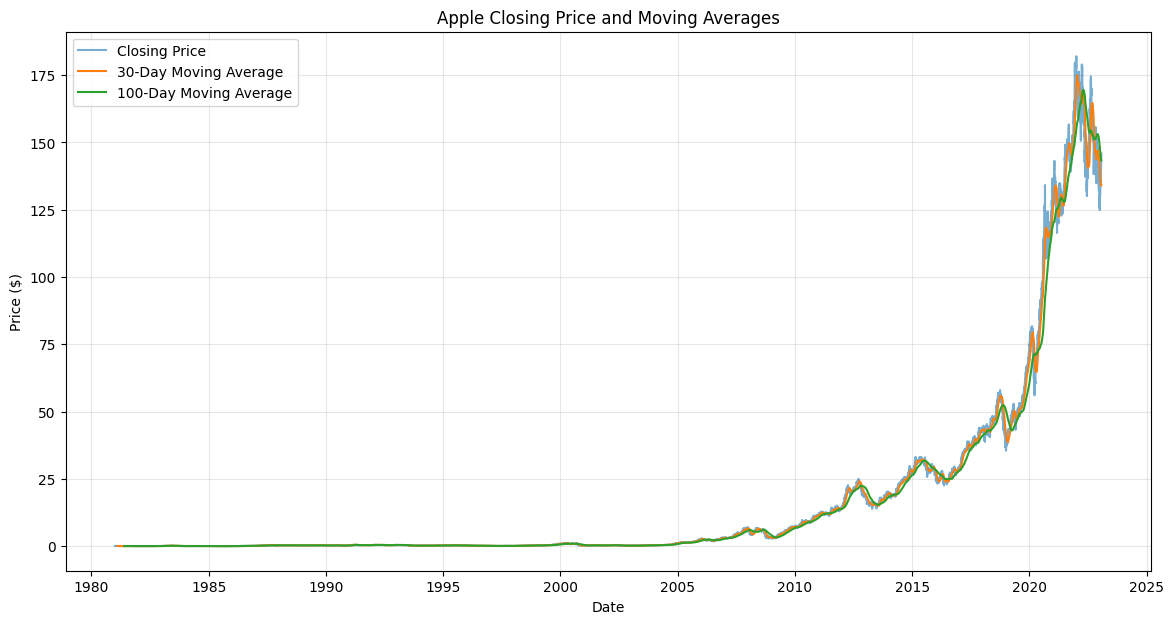

In [24]:
plt.figure(figsize=(14, 7))

plt.plot(df["Date"], df["Close"], label="Closing Price", alpha=0.6)
plt.plot(df["Date"], df["MA30"], label="30-Day Moving Average")
plt.plot(df["Date"], df["MA100"], label="100-Day Moving Average")

plt.title("Apple Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The moving averages smooth short-term price fluctuations and make the underlying trend easier to observe. The 30-day moving average follows changes in Apple's stock price relatively closely, while the 100-day moving average is smoother and reacts more slowly to price movements. Both measures highlight the significant long-term upward trend in Apple's stock price.

Hypothesis Testing

T-test comparing closing prices between years

In [25]:
df["Year"] = df["Date"].dt.year

df["Year"].unique()

array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
      dtype=int32)

In [49]:
prices_2021 = df[df["Year"] == 2021]["Close"].dropna()
prices_2022 = df[df["Year"] == 2022]["Close"].dropna()

print("2021 observations:", len(prices_2021))
print("2022 observations:", len(prices_2022))

print("Mean closing price 2021:", prices_2021.mean())
print("Mean closing price 2022:", prices_2022.mean())

2021 observations: 252
2022 observations: 251
Mean closing price 2021: 140.98936516269842
Mean closing price 2022: 154.83505970119523


In [27]:
prices_year1 = df[df["Year"] == year1]["Close"].dropna()
prices_year2 = df[df["Year"] == year2]["Close"].dropna()

In [50]:
t_stat, p_value = stats.ttest_ind(
    prices_2021,
    prices_2022,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -11.18656637005918
P-value: 4.7097114017662864e-26


In [51]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference between the average closing prices in 2021 and 2022.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of a statistically significant difference.")

Reject the null hypothesis.
There is a statistically significant difference between the average closing prices in 2021 and 2022.


A Welch independent-sample t-test was conducted to compare Apple's average closing prices in 2021 and 2022. The mean closing price was approximately $140.99 in 2021 and $154.84 in 2022.

The test produced a t-statistic of approximately -11.19 and a p-value of 4.71 × 10⁻²⁶. Since the p-value is far below the significance level of 0.05, the null hypothesis is rejected. Therefore, the analysis provides strong statistical evidence that Apple's average closing price differed between 2021 and 2022. The negative t-statistic indicates that the mean closing price in 2021 was lower than the mean closing price in 2022.

Daily Returns

In [30]:
df["Daily_Return"] = df["Close"].pct_change()

In [31]:
df[["Date", "Close", "Daily_Return"]].head()

,Date,Close,Daily_Return
0,1981-01-02,0.154018,NaN
1,1981-01-05,0.150670,-0.021738
2,1981-01-06,0.143973,-0.044448
3,1981-01-07,0.137835,-0.042633
4,1981-01-08,0.135045,-0.020242


In [32]:
df["Daily_Return"].describe()

,Daily_Return
count,10607.000000
mean,0.001052
std,0.028235
min,-0.518692
25%,-0.013109
50%,0.000000
75%,0.014684
max,0.332280


Distribution of Daily Returns

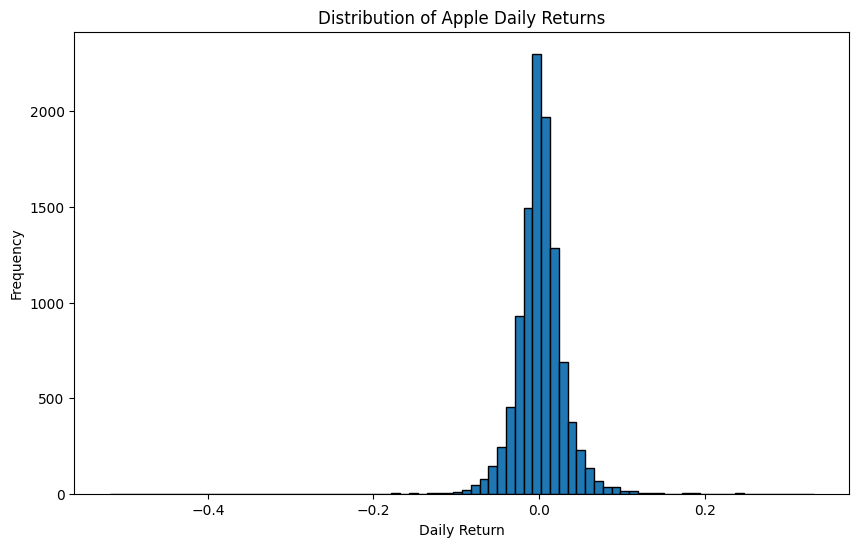

In [33]:
returns = df["Daily_Return"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(returns, bins=80, edgecolor="black")

plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

Most daily returns are concentrated close to zero, while occasional large positive or negative returns create tails on the distribution. Examining the distribution allows us to investigate whether Apple stock returns approximately follow a normal distribution.

Normality Test

In [34]:
statistic, p_value = stats.normaltest(returns)

print("Normality test statistic:", statistic)
print("P-value:", p_value)

Normality test statistic: 2719.205287365936
P-value: 0.0


In [35]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("Daily returns do not appear to follow a normal distribution.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that daily returns are non-normal.")

Reject the null hypothesis.
Daily returns do not appear to follow a normal distribution.


A normality test was performed using SciPy's normaltest() function to determine whether Apple's daily returns follow a normal distribution. The null hypothesis stated that daily returns follow a normal distribution, while the alternative hypothesis stated that they do not.

The test produced a statistic of approximately 2719.21 and a p-value reported as 0.0. The reported value of zero indicates that the p-value is extremely small and below the precision displayed by Python; it should not be interpreted as a literal probability of zero.

Since the p-value is far below the significance level of 0.05, the null hypothesis is rejected. Therefore, there is very strong statistical evidence that Apple's daily returns do not follow a normal distribution.

Advanced Statistical Techniques — Bonus

NumPy convolve() Moving Average

In [36]:
window = 30

weights = np.ones(window) / window

moving_average = np.convolve(
    df["Close"].values,
    weights,
    mode="valid"
)

In [37]:
ma_dates = df["Date"].iloc[window - 1:]

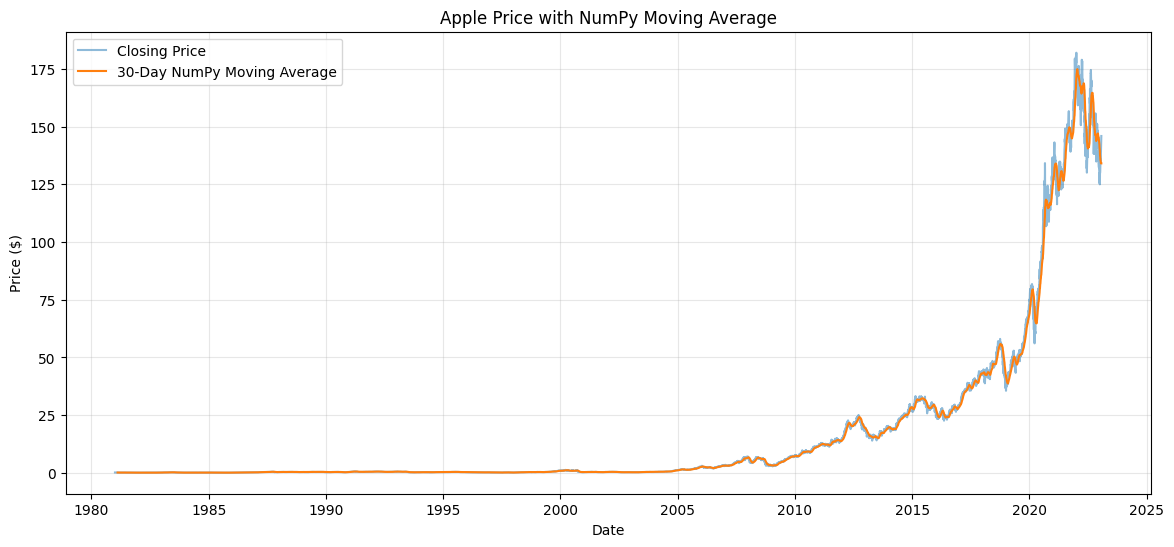

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], alpha=0.5, label="Closing Price")
plt.plot(ma_dates, moving_average, label="30-Day NumPy Moving Average")

plt.title("Apple Price with NumPy Moving Average")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

NumPy's convolve() function was used to calculate a 30-day moving average of Apple's closing price. A set of equal weights was applied across consecutive 30-day windows. The resulting moving average reduces short-term fluctuations and makes the underlying price trend easier to observe. This produces a similar result to Pandas' rolling() method while demonstrating NumPy's array-based statistical capabilities.

Correlation Analysis with np.corrcoef

In [39]:
correlation = np.corrcoef(
    df["Close"],
    df["Volume"]
)

correlation

array([[ 1.        , -0.21493343],
       [-0.21493343,  1.        ]])

In [40]:
close_volume_corr = correlation[0, 1]

print("Correlation between closing price and volume:")
print(close_volume_corr)

Correlation between closing price and volume:
-0.21493342533575596


NumPy's corrcoef() function was used to examine the relationship between Apple's closing stock price and trading volume. The resulting Pearson correlation coefficient was approximately −0.215, indicating a weak negative linear relationship between the two variables.

This suggests that, across the full dataset, higher closing prices tended to be associated with somewhat lower trading volumes. However, the relationship is weak, meaning that closing price alone does not strongly explain variations in trading volume. Additionally, correlation measures association rather than causation.

Moving Average vs Trading Volume

In [41]:
df["Volume_MA30"] = df["Volume"].rolling(30).mean()

In [42]:
correlation_data = df[["MA30", "Volume_MA30"]].dropna()

In [43]:
ma_volume_corr = np.corrcoef(
    correlation_data["MA30"],
    correlation_data["Volume_MA30"]
)[0, 1]

print("Correlation between 30-day price MA and 30-day volume MA:")
print(ma_volume_corr)

Correlation between 30-day price MA and 30-day volume MA:
-0.2710159155381038


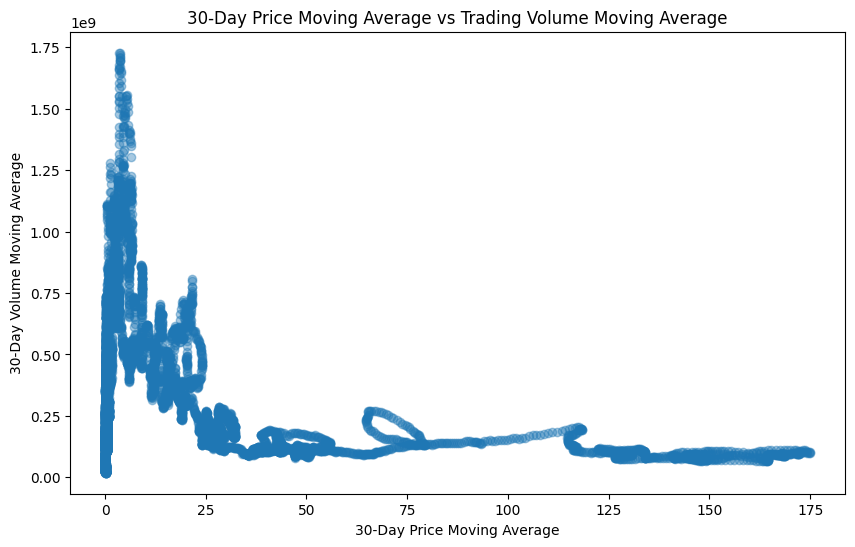

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    correlation_data["MA30"],
    correlation_data["Volume_MA30"],
    alpha=0.4
)

plt.title("30-Day Price Moving Average vs Trading Volume Moving Average")
plt.xlabel("30-Day Price Moving Average")
plt.ylabel("30-Day Volume Moving Average")

plt.show()

The correlation between the 30-day moving average of closing price and the 30-day moving average of trading volume was approximately −0.271. This represents a weak negative linear relationship. Compared with the correlation between raw closing price and raw trading volume (approximately −0.215), smoothing the variables produced a slightly stronger negative association. However, the correlation remains relatively weak, suggesting that changes in trading volume are not strongly explained by changes in Apple's stock price alone.

Signal Processing Using SciPy

In [45]:
close_prices = df["Close"].values

smoothed_prices = savgol_filter(
    close_prices,
    window_length=101,
    polyorder=3
)

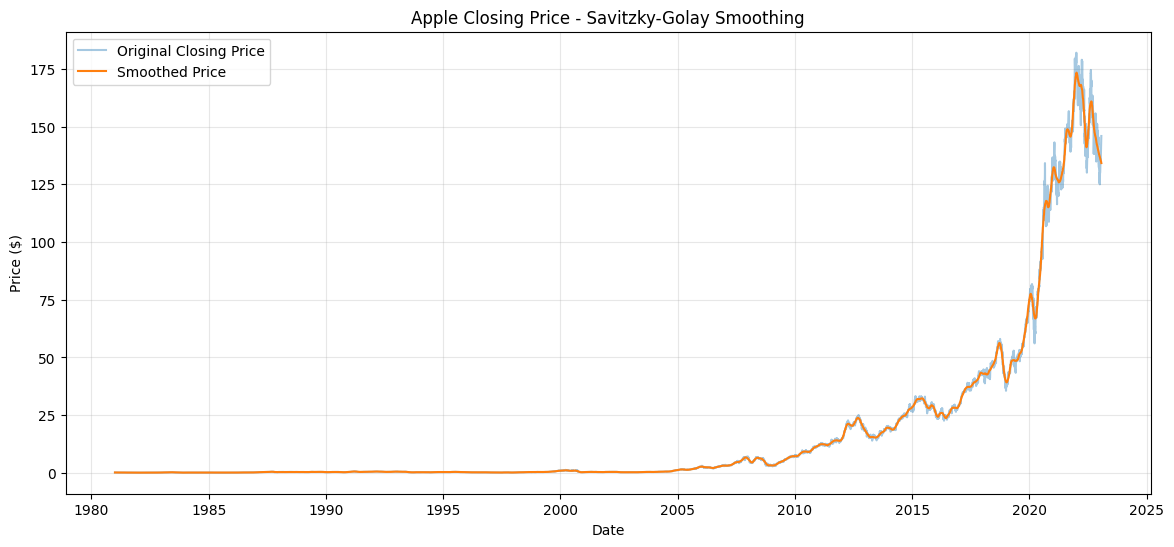

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Close"],
    alpha=0.4,
    label="Original Closing Price"
)

plt.plot(
    df["Date"],
    smoothed_prices,
    label="Smoothed Price"
)

plt.title("Apple Closing Price - Savitzky-Golay Smoothing")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The Savitzky-Golay filter successfully reduced short-term fluctuations in Apple’s closing-price data while preserving the broader shape of the trend. Compared with the original closing-price series, the smoothed line is less volatile but still captures major increases and decreases in price. This demonstrates how signal-processing techniques can help reveal underlying trends in noisy financial time-series data.

Summary and Insights

This project analyzed 10,608 observations of Apple stock data covering January 2, 1981 through January 27, 2023. The dataset contained opening, high, low, closing, adjusted closing, and trading-volume information and had no missing values in the original financial variables.

Visualization of Apple's closing price revealed a substantial long-term upward trend, particularly during the later years of the dataset. Trading volume varied significantly over time and included several periods of unusually high trading activity. Moving-average analysis further demonstrated Apple's long-term price trend while smoothing short-term fluctuations.

Descriptive statistics showed that Apple's mean closing price over the complete dataset was approximately $16.70, while the median was approximately $0.49. The large difference between these measures reflects the strong increase in Apple's stock price during the later portion of the dataset. The standard deviation of the closing price was approximately $35.47, indicating substantial variation across the full period.

Hypothesis testing was used to compare Apple's closing prices in 2021 and 2022. The mean closing price increased from approximately $140.99 in 2021 to $154.84 in 2022. A Welch independent-samples t-test produced a t-statistic of approximately −11.19 and a p-value of approximately 4.71 × 10⁻²⁶. Because this p-value was far below 0.05, the null hypothesis was rejected, providing strong statistical evidence that average closing prices differed between the two years.

Apple's daily returns were also examined for normality. The SciPy normality test produced a statistic of approximately 2719.21 and a p-value effectively equal to zero at machine precision. Therefore, the null hypothesis of normally distributed daily returns was rejected.

Finally, correlation analysis demonstrated a weak negative relationship between closing price and trading volume, with a correlation coefficient of approximately −0.215. The correlation between their 30-day moving averages was approximately −0.271, showing a slightly stronger but still weak negative relationship. NumPy's convolve() and SciPy's signal-processing functions also demonstrated alternative methods for smoothing financial time-series data.

Reflection

One of the main challenges in this project was working with a long time-series dataset. The Date column initially had to be converted from text into datetime format, and it was important to recognize that the dataset used day/month/year formatting. Sorting the observations chronologically was also necessary before performing time-series analysis.

Another challenge was interpreting statistical results correctly. For example, several hypothesis tests produced extremely small p-values that were displayed using scientific notation or as 0.0. I learned that a p-value displayed as 0.0 does not necessarily mean the probability is mathematically zero; instead, the value may be smaller than Python can conveniently represent at the displayed precision.

The project also helped me better understand moving averages and correlation. Moving averages were useful for reducing short-term fluctuations and identifying longer-term patterns, while correlation analysis showed that two variables can have a relationship without necessarily having a strong one. It was also important to remember that correlation does not establish causation.

Overall, this project improved my ability to combine Pandas, NumPy, SciPy, and Matplotlib for real-world statistical analysis. I gained more experience with time-series data, hypothesis testing, moving averages, normality testing, correlations, and signal-processing techniques.

Overall, the project improved my understanding of financial time-series analysis and demonstrated how Python's statistical libraries can be combined to identify trends, relationships, and statistically significant patterns.